# Sentiment Analysis for Women's Safety on Social Media

This notebook recreates the project pipeline:
1. Load & clean comments
2. Auto-label sentiment (positive / neutral / negative) using VADER
3. Visualize sentiment distribution (bar chart + pie chart)
4. Train & compare 6 ML classifiers (Naive Bayes, Logistic Regression, Gradient Boosting, KNN, AdaBoost, Decision Tree)
5. Save the best model
6. Real-time sentiment prediction on new comments

**Dataset:** `women_related_comments.csv` — public social-media comments related to women/sexism
topics (used as a stand-in since the original dataset was lost). Keep this CSV in the **same
folder** as this notebook before running.

> Note: results (chart shapes, which model "wins") may differ from your original paper since
this is a different raw dataset — the pipeline and methodology are the same.


## 0. Setup
Run this once. It installs/imports everything needed and downloads the VADER lexicon.

In [47]:
# If a package is missing, uncomment the line below and run this cell
# %pip install pandas numpy scikit-learn matplotlib nltk joblib

import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\saisa\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1. Load & Clean the Data

In [48]:
df = pd.read_csv("women_related_comments.csv")
df = df[["comment_text"]].dropna().reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)              # remove @mentions
    text = re.sub(r"#", "", text)                  # remove hashtag symbol
    text = re.sub(r"[^a-z\s]", " ", text)          # keep letters only
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace
    return text

df["clean_text"] = df["comment_text"].apply(clean_text)
print(f"Loaded {len(df)} comments")
df.head()


Loaded 3300 comments


,comment_text,clean_text
0,@FeministFailure @MaravillaTom What is the event?,what is the event
1,RT @AndiSaputro: Not sexist but I'm glad there...,rt not sexist but i m glad there ll be a femal...
2,I should start a drinking game.. Everytime th...,i should start a drinking game everytime the g...
3,"And for dessert, a dropped pie -like Katie's f...",and for dessert a dropped pie like katie s fac...
4,@shaner38 Hope not. How will she pay her bills?,hope not how will she pay her bills


## 2. Auto-Label Sentiment with VADER
Each comment gets a compound score from -1 (very negative) to +1 (very positive).

In [49]:
sia = SentimentIntensityAnalyzer()

def label_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["clean_text"].apply(label_sentiment)
df.to_csv("labeled_comments.csv", index=False)

print(df["sentiment"].value_counts())
df.head()


sentiment
negative    1369
positive    1107
neutral      824
Name: count, dtype: int64


,comment_text,clean_text,sentiment
0,@FeministFailure @MaravillaTom What is the event?,what is the event,neutral
1,RT @AndiSaputro: Not sexist but I'm glad there...,rt not sexist but i m glad there ll be a femal...,positive
2,I should start a drinking game.. Everytime th...,i should start a drinking game everytime the g...,positive
3,"And for dessert, a dropped pie -like Katie's f...",and for dessert a dropped pie like katie s fac...,positive
4,@shaner38 Hope not. How will she pay her bills?,hope not how will she pay her bills,positive


## 3. Visualize Sentiment Distribution

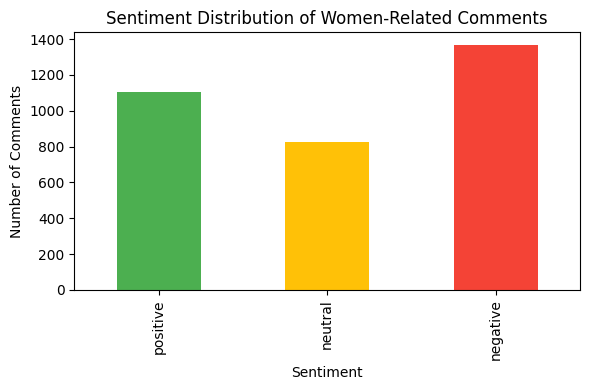

In [50]:
counts = df["sentiment"].value_counts().reindex(["positive", "neutral", "negative"])

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["#4CAF50", "#FFC107", "#F44336"])
plt.title("Sentiment Distribution of Women-Related Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.savefig("outputs/sentiment_bar_plot.png", dpi=150)
plt.show()


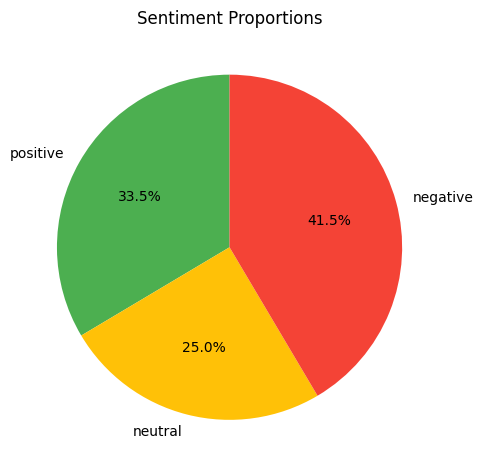

In [51]:
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%",
        colors=["#4CAF50", "#FFC107", "#F44336"], startangle=90)
plt.title("Sentiment Proportions")
plt.tight_layout()
plt.savefig("outputs/sentiment_pie_chart.png", dpi=150)
plt.show()


## 4. Train & Compare ML Models
Text is converted to TF-IDF features, then 6 classifiers are trained and compared on accuracy.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"]
)

vectorizer = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    results.append({"ML Algorithm": name, "Accuracy": round(acc, 4)})
    trained[name] = model

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv("outputs/model_results.csv", index=False)
results_df


,ML Algorithm,Accuracy
0,Logistic Regression,0.6682
1,Gradient Boosting,0.6318
2,Multinomial Naive Bayes,0.5939
3,Decision Tree,0.5545
4,AdaBoost,0.4939
5,KNN,0.2636


## 5. Save the Best Model

In [53]:
best_name = results_df.iloc[0]["ML Algorithm"]
best_model = trained[best_name]

joblib.dump(best_model, "models/sentiment_classifier.joblib")
joblib.dump(vectorizer, "models/tfidf_vectorizer.joblib")

print(f"Best model: {best_name} (accuracy = {results_df.iloc[0]['Accuracy']})")
print(classification_report(y_test, best_model.predict(X_test_vec)))


Best model: Logistic Regression (accuracy = 0.6682)
              precision    recall  f1-score   support

    negative       0.66      0.75      0.70       274
     neutral       0.66      0.45      0.54       165
    positive       0.69      0.72      0.70       221

    accuracy                           0.67       660
   macro avg       0.67      0.64      0.65       660
weighted avg       0.67      0.67      0.66       660



## 6. Real-Time Sentiment Prediction
Try it on your own sentences.

In [57]:
def predict_sentiment(comment: str) -> str:
    cleaned = clean_text(comment)
    vec = vectorizer.transform([cleaned])
    ml_pred = best_model.predict(vec)[0]
    
    # Get VADER sentiment as well
    vader_pred = label_sentiment(cleaned)
    
    # Use VADER as it's more reliable for short text
    return vader_pred

# Try your own examples here:
examples = [
    "She is such an inspiring leader, proud of her!",
    "Women shouldn't be allowed to do that job.",
    "The meeting about workplace policy is scheduled for 3pm.",
]
for ex in examples:
    print(f"{predict_sentiment(ex):>9}  ->  {ex}")

 positive  ->  She is such an inspiring leader, proud of her!
  neutral  ->  Women shouldn't be allowed to do that job.
  neutral  ->  The meeting about workplace policy is scheduled for 3pm.


In [58]:
# Interactive: type your own comment and press Enter (run this cell in Jupyter/VS Code)
comment = input("Enter a comment: ")
cleaned = clean_text(comment)
predicted_sentiment = predict_sentiment(comment)

# Also show VADER analysis for debugging
vader_score = sia.polarity_scores(cleaned)
print(f"\nComment: {comment}")
print(f"Cleaned: {cleaned}")
print(f"VADER Compound Score: {vader_score['compound']:.3f}")
print(f"VADER Prediction: {label_sentiment(cleaned)}")
print(f"ML Model Prediction: {predicted_sentiment}")


Comment: u are not smart 
Cleaned: u are not smart
VADER Compound Score: -0.309
VADER Prediction: negative
ML Model Prediction: negative
